# Stacked Ensemble Model for Nigerian CPI Forecasting

## Project Structure
- All development in this single notebook
- Data: data/master_dataset_full.csv
- Models: models/
- Plots: output/
- Predictions: prediction/
- Web App: app.py (root)

We will build base learners (SARIMAX, Random Forest, LSTM) and stack them with XGBoost.
Target: Forecast shifts in Food, Transport, Clothing & Footwear, Health, Housing.
User inputs: inflation_rate, exchange_rate, crude_oil_price.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime

# Create necessary folders
os.makedirs('../models', exist_ok=True)
os.makedirs('../output', exist_ok=True)
os.makedirs('../prediction', exist_ok=True)

print("Folders ready!")

Folders ready!


In [2]:
# ====================== PHASE 1: DATA LOADING ======================
def load_data():
    file_path = '../data/master_dataset_full.csv'
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"CSV not found at {file_path}. Please place master_dataset_full.csv in the data/ folder.")
    
    df = pd.read_csv(file_path)
    
    # Fix date column (it's the first unnamed column)
    df = df.rename(columns={df.columns[0]: 'date'})
    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date')
    
    print(f"✅ Data loaded successfully!")
    print(f"Shape: {df.shape}")
    print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")
    
    return df

# Load the data
df = load_data()
df.head()

✅ Data loaded successfully!
Shape: (312, 22)
Date range: 2000-01-01 to 2025-12-01


,All Items,All Items Less Farm Produce,All Items Less Farm Produce And Energy,Imported Food,Food,Food And Non Alcoholic Bev,Alcoholic Beverage Tobacco And Kola,Clothing And Footwear,Housing Water Electricity Gas And Other Fuel,Furnishings And Household Equipment Maintenance,...,Communication,Recreation And Culture,Education,Restaurant And Hotels,Miscellaneous Goods And Services,Food And Non-Alcoholic Beverages,exchange_rate,crude_oil_price,domestic_production,crude_oil_export
date,,,,,,,,,,,,,,,,,,,,,
2000-01-01,29.38,31.17,37.06,100.0,29.13,28.78,31.88,54.54,24.09,45.74,...,40.32,38.38,30.97,30.51,26.03,85.122399,98.90,63.85,2.59,2.14
2000-02-01,29.74,31.31,37.25,100.0,29.59,29.26,31.93,54.55,24.05,45.22,...,40.32,39.40,30.97,30.51,26.54,85.122399,100.20,63.85,2.59,2.14
2000-03-01,30.06,31.86,37.71,100.0,29.78,29.47,32.46,54.26,24.69,46.92,...,40.32,40.14,30.97,30.51,26.80,85.122399,100.12,63.85,2.59,2.14
2000-04-01,30.66,32.46,37.88,100.0,30.33,29.98,33.26,55.06,25.79,47.19,...,40.32,39.49,30.97,30.51,27.01,85.122399,99.87,63.85,2.59,2.14
2000-05-01,31.62,33.77,38.31,100.0,31.04,30.65,34.59,55.23,27.94,46.88,...,40.32,39.68,30.97,30.51,28.07,85.122399,100.70,63.85,2.59,2.14


## Phase 2: Data Cleaning & EDA

We will:
- Derive inflation_rate from 'All Items'
- Select the 5 target CPI categories
- Check for missing values
- Explore trends, correlations, and stationarity
- Save plots to ../output/

In [3]:
# ====================== PHASE 2: DATA CLEANING ======================

# Select key columns
targets = [
    'Food',
    'Transport',
    'Clothing And Footwear',
    'Health',
    'Housing Water Electricity Gas And Other  Fuel'
]

macros = ['exchange_rate', 'crude_oil_price']

# Keep All Items for inflation derivation
df_clean = df[['All Items'] + targets + macros].copy()

# Derive inflation rate (month-on-month % change)
df_clean['inflation_rate'] = df_clean['All Items'].pct_change() * 100

# Check missing values
print("Missing values:\n", df_clean.isnull().sum())

# Forward fill any remaining missing values (safe for time series)
df_clean = df_clean.fillna(method='ffill')

print(f"\n✅ Cleaned Data Shape: {df_clean.shape}")
print("Columns:", df_clean.columns.tolist())
df_clean.head()

Missing values:
 All Items                                        0
Food                                             0
Transport                                        0
Clothing And Footwear                            0
Health                                           0
Housing Water Electricity Gas And Other  Fuel    0
exchange_rate                                    0
crude_oil_price                                  0
inflation_rate                                   1
dtype: int64

✅ Cleaned Data Shape: (312, 9)
Columns: ['All Items', 'Food', 'Transport', 'Clothing And Footwear', 'Health', 'Housing Water Electricity Gas And Other  Fuel', 'exchange_rate', 'crude_oil_price', 'inflation_rate']


C:\Users\chimb\AppData\Local\Temp\ipykernel_36748\1999770256.py:24: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_clean = df_clean.fillna(method='ffill')


,All Items,Food,Transport,Clothing And Footwear,Health,Housing Water Electricity Gas And Other Fuel,exchange_rate,crude_oil_price,inflation_rate
date,,,,,,,,,
2000-01-01,29.38,29.13,34.64,54.54,57.48,24.09,98.90,63.85,NaN
2000-02-01,29.74,29.59,35.45,54.55,58.22,24.05,100.20,63.85,1.225323
2000-03-01,30.06,29.78,35.23,54.26,57.95,24.69,100.12,63.85,1.075992
2000-04-01,30.66,30.33,35.33,55.06,57.92,25.79,99.87,63.85,1.996008
2000-05-01,31.62,31.04,36.03,55.23,60.82,27.94,100.70,63.85,3.131115


In [4]:
# Save cleaned data directly in data/ folder
df_clean.to_csv('../data/cleaned_cpi_data.csv')
print("✅ Cleaned data saved to ../data/cleaned_cpi_data.csv")

✅ Cleaned data saved to ../data/cleaned_cpi_data.csv


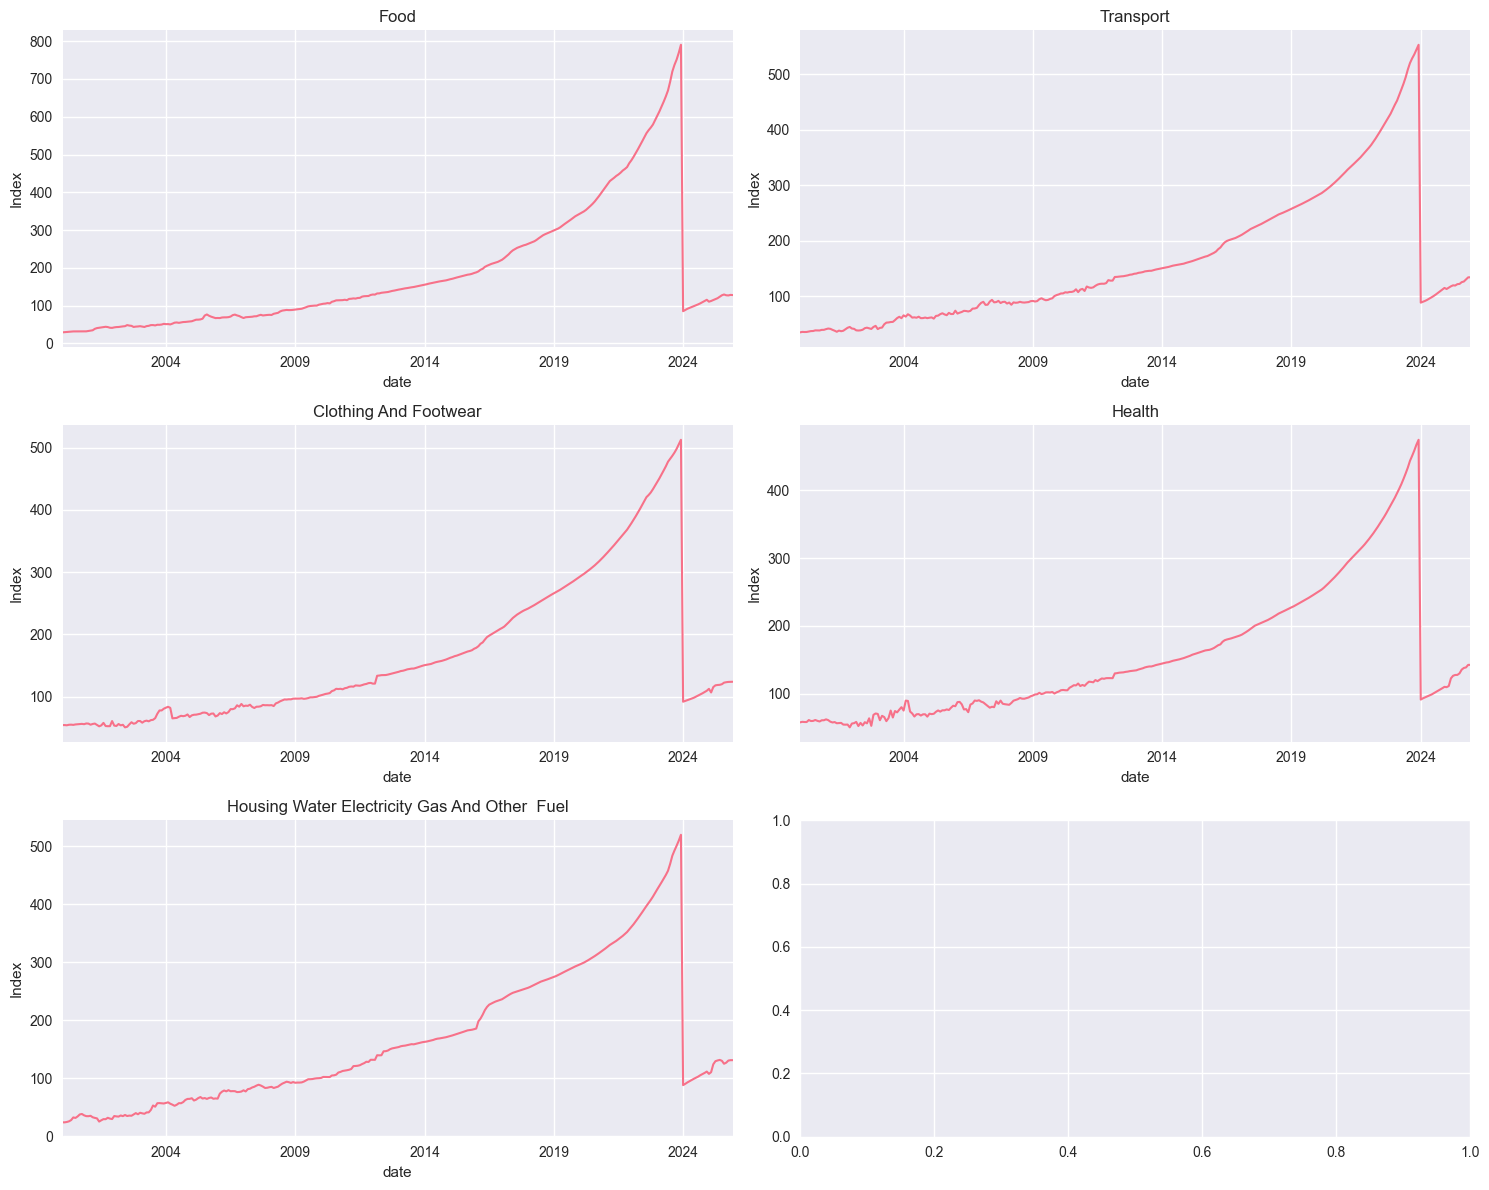

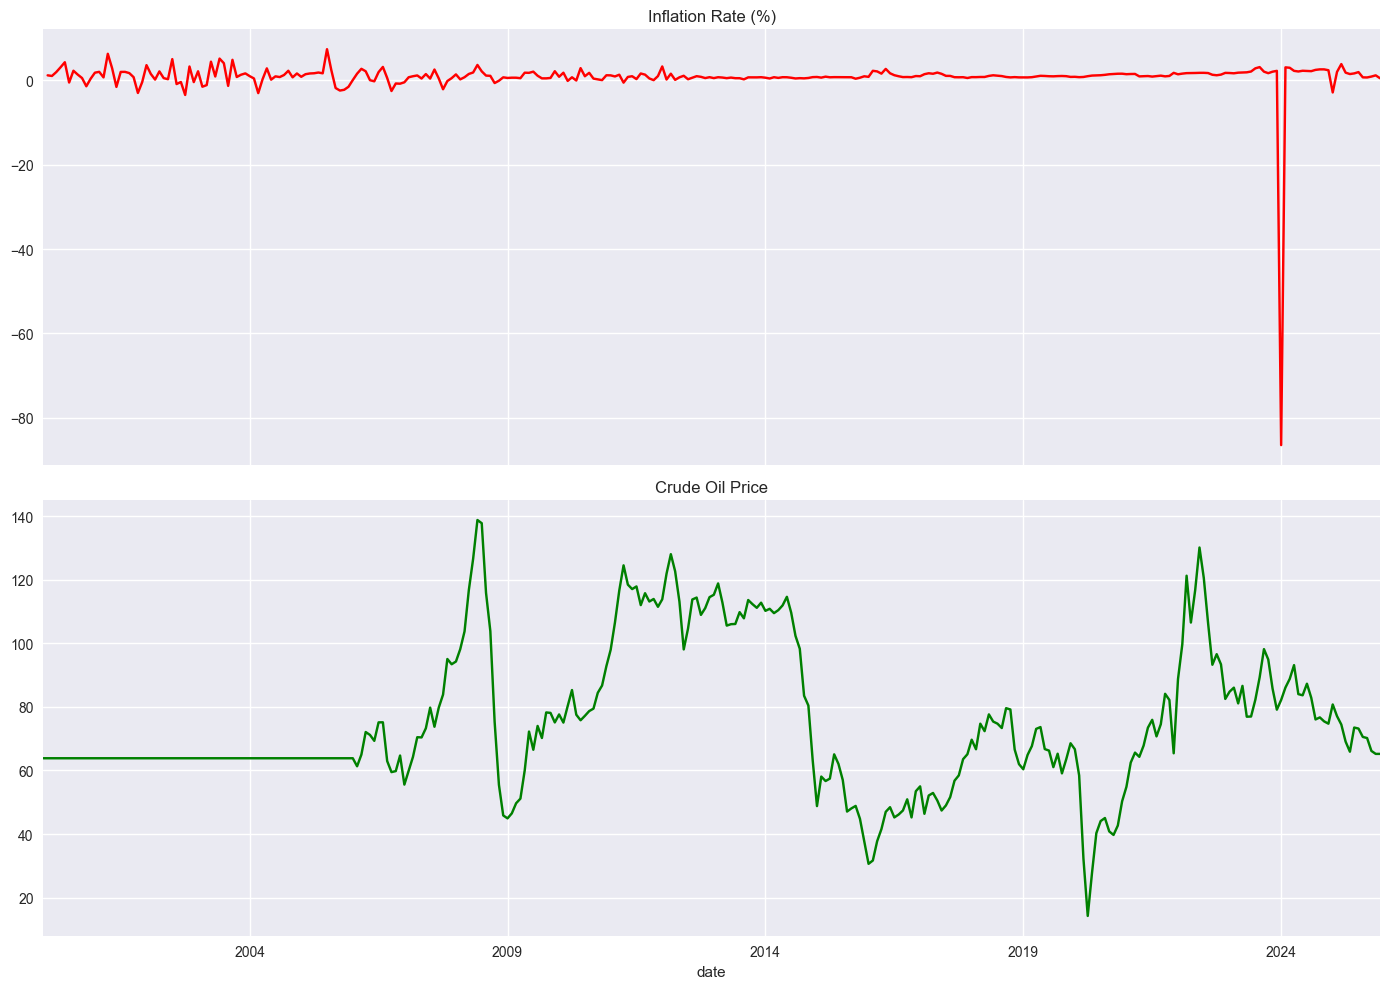

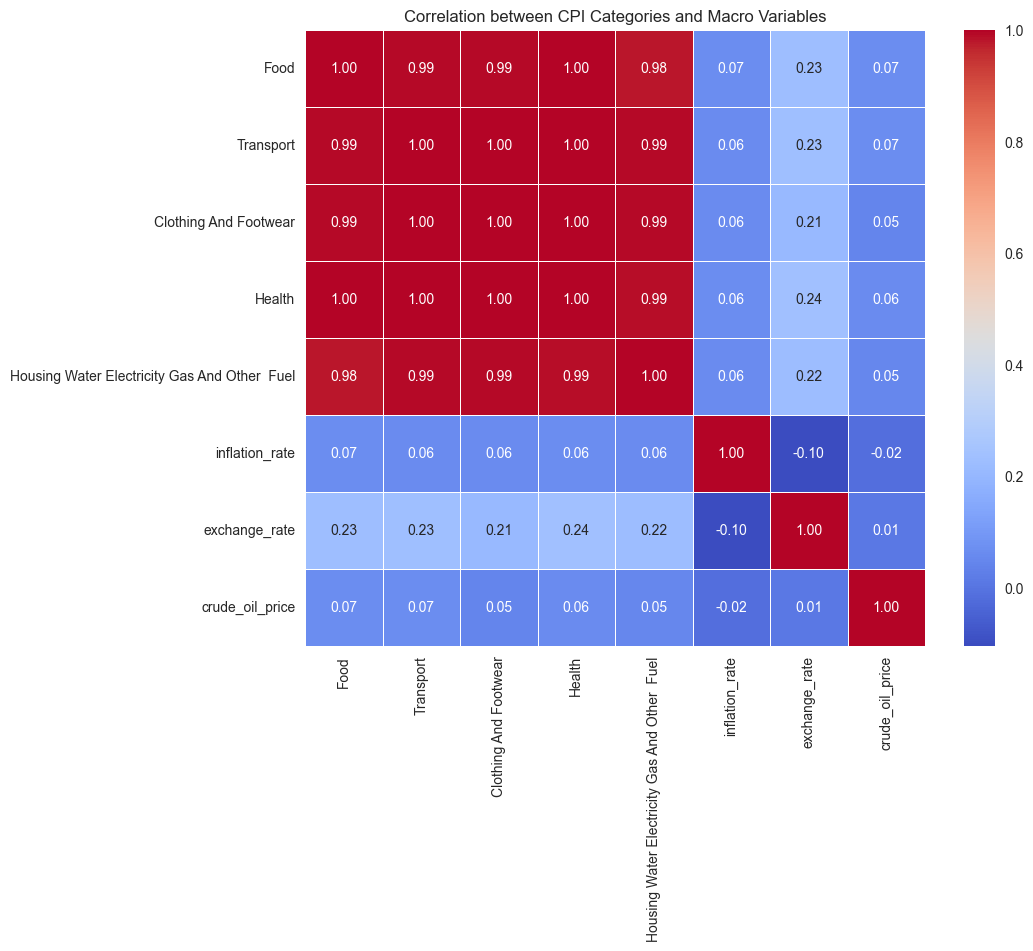

✅ EDA plots saved to ../output/ folder


In [5]:
# ====================== EXPLORATORY DATA ANALYSIS ======================

import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# 1. Plot the 5 target categories
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.ravel()

for i, target in enumerate(targets):
    df_clean[target].plot(ax=axes[i], title=target, linewidth=1.5)
    axes[i].set_ylabel('Index')
    axes[i].grid(True)

plt.tight_layout()
plt.savefig('../output/cpi_targets_trends.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Plot macros + inflation
fig, ax = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

df_clean['inflation_rate'].plot(ax=ax[0], title='Inflation Rate (%)', color='red')
ax[0].grid(True)

df_clean['crude_oil_price'].plot(ax=ax[1], title='Crude Oil Price', color='green')
ax[1].grid(True)

plt.tight_layout()
plt.savefig('../output/macros_and_inflation.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Correlation heatmap
plt.figure(figsize=(10, 8))
corr = df_clean[targets + ['inflation_rate', 'exchange_rate', 'crude_oil_price']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation between CPI Categories and Macro Variables')
plt.savefig('../output/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ EDA plots saved to ../output/ folder")

## Phase 3: Feature Engineering & Time-Series Splitting

We will:
- Create month-on-month % change targets for the 5 CPI categories
- Add economic event dummy variables
- Generate lags, rolling statistics, and seasonal features
- Perform time-based split (no leakage)
- Save engineered dataset

In [6]:
# ====================== FEATURE ENGINEERING ======================

# Create month-on-month % change targets (our main modeling target)
for target in targets:
    df_clean[f'{target}_mom_pct'] = df_clean[target].pct_change() * 100

# Economic event dummies (based on major Nigerian shocks)
df_clean['subsidy_removal_2023'] = 0
df_clean.loc['2023-06-01':, 'subsidy_removal_2023'] = 1   # June 2023 onward

df_clean['fx_unification_2023'] = 0
df_clean.loc['2023-06-01':, 'fx_unification_2023'] = 1

df_clean['covid_period'] = 0
df_clean.loc['2020-03-01':'2021-12-31', 'covid_period'] = 1

print("Event dummies created. Quick check around 2023:")
print(df_clean[['subsidy_removal_2023', 'fx_unification_2023']].loc['2023-05-01':'2023-08-01'])

# Feature engineering for each target (we'll do it per target later, but create shared features now)
def create_features(df, target_col):
    features = df.copy()
    
    # Lags of target MoM % change (1 to 12 months)
    for lag in range(1, 13):
        features[f'{target_col}_lag_{lag}'] = features[target_col].shift(lag)
    
    # Rolling statistics on target MoM
    for window in [3, 6, 12]:
        features[f'{target_col}_roll_mean_{window}'] = features[target_col].rolling(window=window).mean()
        features[f'{target_col}_roll_std_{window}'] = features[target_col].rolling(window=window).std()
    
    # Macro features + lags
    macros = ['inflation_rate', 'exchange_rate', 'crude_oil_price']
    for macro in macros:
        for lag in range(0, 4):  # current + 3 lags
            features[f'{macro}_lag_{lag}'] = features[macro].shift(lag)
    
    # Seasonal features
    features['month'] = features.index.month
    features['quarter'] = features.index.quarter
    
    # Sine/cosine for seasonality
    features['month_sin'] = np.sin(2 * np.pi * features['month'] / 12)
    features['month_cos'] = np.cos(2 * np.pi * features['month'] / 12)
    
    return features

print("✅ Feature engineering functions ready. Event dummies added.")

Event dummies created. Quick check around 2023:
            subsidy_removal_2023  fx_unification_2023
date                                                 
2023-05-01                     0                    0
2023-06-01                     1                    1
2023-07-01                     1                    1
2023-08-01                     1                    1
✅ Feature engineering functions ready. Event dummies added.


In [7]:
# ====================== TIME-BASED SPLIT ======================

# Use cleaned data with features (we'll apply per target later)
# For now, split the base dataframe

# Recommended split: Train until ~Dec 2020, Val 2021-2022, Test 2023+
train_end = '2020-12-31'
val_end = '2022-12-31'

train_df = df_clean.loc[:train_end].copy()
val_df = df_clean.loc[train_end:val_end].copy()
test_df = df_clean.loc[val_end:].copy()

print(f"Train shape: {train_df.shape} ({train_df.index.min().date()} to {train_df.index.max().date()})")
print(f"Val shape:   {val_df.shape} ({val_df.index.min().date()} to {val_df.index.max().date()})")
print(f"Test shape:  {test_df.shape} ({test_df.index.min().date()} to {test_df.index.max().date()})")

# Save engineered base data
df_clean.to_csv('../data/cleaned_cpi_data_with_features.csv')
print("✅ Base data with features saved to ../data/")

Train shape: (252, 17) (2000-01-01 to 2020-12-01)
Val shape:   (24, 17) (2021-01-01 to 2022-12-01)
Test shape:  (36, 17) (2023-01-01 to 2025-12-01)
✅ Base data with features saved to ../data/


## Phase 4: Base Learner 1 - SARIMAX (ARIMA with Exogenous Variables)

We will train one SARIMAX model per CPI category.
Target: Month-on-month % change
Exogenous: inflation_rate, exchange_rate, crude_oil_price + event dummies
Using pmdarima.auto_arima for order selection (with seasonality).

In [8]:
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.statespace.sarimax import SARIMAX
import pmdarima as pm
import joblib
import os

# Prepare features for SARIMAX (exogenous only)
exog_cols = ['inflation_rate', 'exchange_rate', 'crude_oil_price',
             'subsidy_removal_2023', 'fx_unification_2023', 'covid_period']

# Function to train SARIMAX for one target
def train_sarimax(target_mom_col, train_data, val_data, exog_cols):
    print(f"\n=== Training SARIMAX for {target_mom_col} ===")
    
    y_train = train_data[target_mom_col].dropna()
    X_train = train_data[exog_cols].loc[y_train.index]
    X_val = val_data[exog_cols]
    
    # Drop any remaining NaNs
    y_train = y_train.dropna()
    X_train = X_train.loc[y_train.index].dropna()
    
    # Auto order selection (can take time)
    print("Running auto_arima for order selection...")
    auto_model = pm.auto_arima(
        y_train,
        exogenous=X_train,
        seasonal=True,
        m=12,                    # monthly seasonality
        start_p=0, start_q=0,
        max_p=3, max_q=3,
        start_P=0, start_Q=0,
        max_P=2, max_Q=2,
        d=None, D=None,
        trace=False,
        error_action='ignore',
        suppress_warnings=True,
        stepwise=True,
        n_fits=50
    )
    
    print(f"Best SARIMAX order: {auto_model.order}, Seasonal: {auto_model.seasonal_order}")
    
    # Fit final SARIMAX model with statsmodels (better for forecasting)
    model = SARIMAX(
        y_train,
        exog=X_train,
        order=auto_model.order,
        seasonal_order=auto_model.seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    
    sarimax_fit = model.fit(disp=False)
    print("SARIMAX model fitted successfully.")
    
    # Save the model
    model_path = f'../models/sarimax_{target_mom_col.replace("_mom_pct", "")}.pkl'
    joblib.dump(sarimax_fit, model_path)
    print(f"Model saved to {model_path}")
    
    return sarimax_fit, auto_model.order, auto_model.seasonal_order

# Dictionary to store fitted models
sarimax_models = {}

# Train for each target
mom_targets = [f'{t}_mom_pct' for t in targets]

for mom_col in mom_targets:
    model_fit, order, seasonal_order = train_sarimax(
        mom_col, 
        train_df, 
        val_df, 
        exog_cols
    )
    sarimax_models[mom_col] = {
        'model': model_fit,
        'order': order,
        'seasonal_order': seasonal_order
    }

print("\n✅ All SARIMAX models trained and saved in ../models/ folder!")


=== Training SARIMAX for Food_mom_pct ===
Running auto_arima for order selection...
Best SARIMAX order: (0, 0, 1), Seasonal: (0, 0, 1, 12)


c:\Users\chimb\Desktop\Consumer Goods Price Dynamics\forecast\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\chimb\Desktop\Consumer Goods Price Dynamics\forecast\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


SARIMAX model fitted successfully.
Model saved to ../models/sarimax_Food.pkl

=== Training SARIMAX for Transport_mom_pct ===
Running auto_arima for order selection...
Best SARIMAX order: (1, 0, 2), Seasonal: (0, 0, 1, 12)


c:\Users\chimb\Desktop\Consumer Goods Price Dynamics\forecast\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\chimb\Desktop\Consumer Goods Price Dynamics\forecast\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


SARIMAX model fitted successfully.
Model saved to ../models/sarimax_Transport.pkl

=== Training SARIMAX for Clothing And Footwear_mom_pct ===
Running auto_arima for order selection...
Best SARIMAX order: (2, 0, 2), Seasonal: (0, 0, 0, 12)


c:\Users\chimb\Desktop\Consumer Goods Price Dynamics\forecast\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\chimb\Desktop\Consumer Goods Price Dynamics\forecast\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\chimb\Desktop\Consumer Goods Price Dynamics\forecast\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMAX model fitted successfully.
Model saved to ../models/sarimax_Clothing And Footwear.pkl

=== Training SARIMAX for Health_mom_pct ===
Running auto_arima for order selection...
Best SARIMAX order: (1, 0, 0), Seasonal: (0, 0, 0, 12)
SARIMAX model fitted successfully.
Model saved to ../models/sarimax_Health.pkl

=== Training SARIMAX for Housing Water Electricity Gas And Other  Fuel_mom_pct ===
Running auto_arima for order selection...


c:\Users\chimb\Desktop\Consumer Goods Price Dynamics\forecast\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\chimb\Desktop\Consumer Goods Price Dynamics\forecast\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Best SARIMAX order: (0, 0, 0), Seasonal: (1, 0, 0, 12)
SARIMAX model fitted successfully.
Model saved to ../models/sarimax_Housing Water Electricity Gas And Other  Fuel.pkl

✅ All SARIMAX models trained and saved in ../models/ folder!


c:\Users\chimb\Desktop\Consumer Goods Price Dynamics\forecast\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\chimb\Desktop\Consumer Goods Price Dynamics\forecast\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


## Phase 4 (continued): Base Learner 2 - Random Forest Regressor

We will train one Random Forest model per target using:
- All lagged features, rolling statistics, seasonal features
- Macro variables and event dummies
- Hyperparameters tuned lightly with TimeSeriesSplit

In [9]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib

# Prepare full feature set for Random Forest (per target)
def prepare_rf_features(df, target_mom_col):
    # Base columns
    feature_cols = [
        'inflation_rate', 'exchange_rate', 'crude_oil_price',
        'subsidy_removal_2023', 'fx_unification_2023', 'covid_period',
        'month', 'quarter', 'month_sin', 'month_cos'
    ]
    
    # Add target-specific lags and rolling stats
    for lag in range(1, 13):
        feature_cols.append(f'{target_mom_col}_lag_{lag}')
    for window in [3, 6, 12]:
        feature_cols.append(f'{target_mom_col}_roll_mean_{window}')
        feature_cols.append(f'{target_mom_col}_roll_std_{window}')
    
    # Add macro lags
    macros = ['inflation_rate', 'exchange_rate', 'crude_oil_price']
    for macro in macros:
        for lag in range(1, 4):   # lags 1-3
            feature_cols.append(f'{macro}_lag_{lag}')
    
    # Keep only columns that exist
    available_features = [col for col in feature_cols if col in df.columns]
    
    X = df[available_features].copy()
    y = df[target_mom_col].copy()
    
    # Drop rows with NaN (from lagging)
    valid_idx = X.dropna().index
    X = X.loc[valid_idx]
    y = y.loc[valid_idx]
    
    return X, y, available_features

# Train Random Forest for one target
def train_random_forest(target_mom_col, train_data):
    print(f"\n=== Training Random Forest for {target_mom_col} ===")
    
    X_train, y_train, feature_names = prepare_rf_features(train_data, target_mom_col)
    
    # TimeSeries cross-validation
    tscv = TimeSeriesSplit(n_splits=5)
    
    # Light hyperparameter grid
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [None, 10, 15],
        'min_samples_split': [2, 5]
    }
    
    rf = RandomForestRegressor(random_state=42, n_jobs=-1)
    
    grid_search = GridSearchCV(
        rf, param_grid, cv=tscv, scoring='neg_mean_absolute_error',
        n_jobs=-1, verbose=1
    )
    
    grid_search.fit(X_train, y_train)
    
    best_rf = grid_search.best_estimator_
    print(f"Best parameters: {grid_search.best_params_}")
    print(f"CV MAE: {-grid_search.best_score_:.4f}")
    
    # Save model
    model_name = target_mom_col.replace('_mom_pct', '')
    model_path = f'../models/rf_{model_name}.pkl'
    joblib.dump(best_rf, model_path)
    print(f"Random Forest model saved to {model_path}")
    
    # Feature importance (top 10)
    importances = pd.Series(best_rf.feature_importances_, index=feature_names).sort_values(ascending=False)
    print("Top 10 important features:")
    print(importances.head(10))
    
    return best_rf, feature_names

# Train for all targets
rf_models = {}
for mom_col in mom_targets:
    best_model, feat_names = train_random_forest(mom_col, train_df)
    rf_models[mom_col] = {'model': best_model, 'features': feat_names}

print("\n✅ All Random Forest models trained and saved!")


=== Training Random Forest for Food_mom_pct ===
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters: {'max_depth': 15, 'min_samples_split': 5, 'n_estimators': 200}
CV MAE: 0.7243
Random Forest model saved to ../models/rf_Food.pkl
Top 10 important features:
inflation_rate          0.863497
exchange_rate           0.108992
crude_oil_price         0.027504
covid_period            0.000007
subsidy_removal_2023    0.000000
fx_unification_2023     0.000000
dtype: float64

=== Training Random Forest for Transport_mom_pct ===
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
CV MAE: 1.7456
Random Forest model saved to ../models/rf_Transport.pkl
Top 10 important features:
inflation_rate          0.470559
exchange_rate           0.444102
crude_oil_price         0.085335
covid_period            0.000004
subsidy_removal_2023    0.000000
fx_unification_2023     0.000000
dtype: floa

## Phase 4 (continued): Base Learner 3 - LSTM

We will train a multivariate LSTM for each target.
- Input: sequences of past values (lags of target MoM + macros)
- We'll use MinMaxScaler per target
- Architecture: LSTM layers + Dense output
- Early stopping to prevent overfitting

In [10]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import joblib

# Set random seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# ====================== FIX: Apply Full Feature Engineering ======================
print("Applying full feature engineering to train, val, and test sets...")

def create_full_features(df, targets):
    df = df.copy()
    
    # Ensure seasonal features exist
    if 'month' not in df.columns:
        df['month'] = df.index.month
        df['quarter'] = df.index.quarter
        df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
        df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    
    # Create lags and rolling for each target MoM
    for target in targets:
        mom_col = f'{target}_mom_pct'
        if mom_col in df.columns:
            for lag in range(1, 13):
                df[f'{mom_col}_lag_{lag}'] = df[mom_col].shift(lag)
            for window in [3, 6, 12]:
                df[f'{mom_col}_roll_mean_{window}'] = df[mom_col].rolling(window=window).mean()
                df[f'{mom_col}_roll_std_{window}'] = df[mom_col].rolling(window=window).std()
    
    return df

# Apply to all splits
train_df_fe = create_full_features(train_df, targets)
val_df_fe   = create_full_features(val_df, targets)
test_df_fe  = create_full_features(test_df, targets)   # for later use

print(f"Feature engineering applied. Train shape now: {train_df_fe.shape}")
print("Sample columns:", [col for col in train_df_fe.columns if 'lag' in col or 'sin' in col][:10])

# ====================== LSTM TRAINING ======================

# Parameters
sequence_length = 12
lstm_units = 50
epochs = 80          # Reduced a bit to speed up
batch_size = 16

def create_sequences(X, y, seq_length):
    Xs, ys = [], []
    for i in range(len(X) - seq_length):
        Xs.append(X[i:(i + seq_length)])
        ys.append(y[i + seq_length])
    return np.array(Xs), np.array(ys)

def train_lstm(target_mom_col, train_data_fe, val_data_fe):
    print(f"\n=== Training LSTM for {target_mom_col} ===")
    
    # Simpler feature set for LSTM (to keep dimensionality reasonable)
    feature_cols = ['inflation_rate', 'exchange_rate', 'crude_oil_price',
                    'subsidy_removal_2023', 'fx_unification_2023', 'covid_period',
                    'month_sin', 'month_cos']
    
    # Add target lags 1-6
    for lag in range(1, 7):
        feature_cols.append(f'{target_mom_col}_lag_{lag}')
    
    X_train = train_data_fe[feature_cols].copy()
    y_train = train_data_fe[target_mom_col].copy()
    
    X_val = val_data_fe[feature_cols].copy()
    y_val = val_data_fe[target_mom_col].copy()
    
    # Drop NaNs caused by lagging
    X_train = X_train.dropna()
    y_train = y_train.loc[X_train.index]
    
    X_val = X_val.dropna()
    y_val = y_val.loc[X_val.index]
    
    # Scaling
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()
    
    X_train_scaled = scaler_X.fit_transform(X_train)
    y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
    
    X_val_scaled = scaler_X.transform(X_val)
    y_val_scaled = scaler_y.transform(y_val.values.reshape(-1, 1))
    
    # Create sequences
    X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, sequence_length)
    X_val_seq, y_val_seq     = create_sequences(X_val_scaled, y_val_scaled, sequence_length)
    
    print(f"Training sequences shape: {X_train_seq.shape}")
    
    # Build model
    model = Sequential([
        LSTM(lstm_units, return_sequences=True, input_shape=(sequence_length, X_train_seq.shape[2])),
        Dropout(0.2),
        LSTM(lstm_units // 2),
        Dropout(0.2),
        Dense(1)
    ])
    
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    
    early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    
    history = model.fit(
        X_train_seq, y_train_seq,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_val_seq, y_val_seq),
        callbacks=[early_stop],
        verbose=1
    )
    
    # Save
    model_name = target_mom_col.replace('_mom_pct', '')
    model_path = f'../models/lstm_{model_name}.h5'
    model.save(model_path)
    
    scaler_path = f'../models/lstm_scaler_{model_name}.pkl'
    joblib.dump({'scaler_X': scaler_X, 'scaler_y': scaler_y}, scaler_path)
    
    print(f"LSTM model and scalers saved for {model_name}")
    return model, scaler_X, scaler_y, history

# Train all LSTMs
lstm_models = {}
mom_targets = [f'{t}_mom_pct' for t in targets]

for mom_col in mom_targets:
    lstm_model, sc_X, sc_y, hist = train_lstm(mom_col, train_df_fe, val_df_fe)
    lstm_models[mom_col] = {'model': lstm_model, 'scaler_X': sc_X, 'scaler_y': sc_y}

print("\n✅ All LSTM models trained and saved!")

Applying full feature engineering to train, val, and test sets...
Feature engineering applied. Train shape now: (252, 111)
Sample columns: ['Housing Water Electricity Gas And Other  Fuel', 'Housing Water Electricity Gas And Other  Fuel_mom_pct', 'month_sin', 'Food_mom_pct_lag_1', 'Food_mom_pct_lag_2', 'Food_mom_pct_lag_3', 'Food_mom_pct_lag_4', 'Food_mom_pct_lag_5', 'Food_mom_pct_lag_6', 'Food_mom_pct_lag_7']

=== Training LSTM for Food_mom_pct ===
Training sequences shape: (233, 12, 14)
Epoch 1/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - loss: 0.0288 - mae: 0.1333 - val_loss: 6.7371e-04 - val_mae: 0.0208
Epoch 2/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0130 - mae: 0.0835 - val_loss: 5.8205e-04 - val_mae: 0.0192
Epoch 3/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0131 - mae: 0.0818 - val_loss: 4.0207e-04 - val_mae: 0.0157
Epoch 4/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0120 - mae: 0.0779 - val_loss: 7.1497e-04 - val_mae: 0.0201
Epoch 5/80
15/15 ━━━━━━

LSTM model and scalers saved for Food

=== Training LSTM for Transport_mom_pct ===
Training sequences shape: (233, 12, 14)
Epoch 1/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - loss: 0.0452 - mae: 0.1669 - val_loss: 1.3119e-04 - val_mae: 0.0090
Epoch 2/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0242 - mae: 0.1132 - val_loss: 0.0062 - val_mae: 0.0778
Epoch 3/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0181 - mae: 0.1012 - val_loss: 2.2064e-04 - val_mae: 0.0122
Epoch 4/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0156 - mae: 0.0886 - val_loss: 1.9048e-04 - val_mae: 0.0119
Epoch 5/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0172 - mae: 0.0965 - val_loss: 1.8138e-04 - val_mae: 0.0122
Epoch 6/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0158 - mae: 0.0915 - val_loss: 1.6282e-04 - val_mae: 0.0095
Epoch 7/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0177 - mae: 0.0971 - val_loss: 1.1347e-04 - val_mae: 0.0074
Epoch 8/80
15/15 ━━━━━━━━━━━━━━━━━

LSTM model and scalers saved for Transport

=== Training LSTM for Clothing And Footwear_mom_pct ===
Training sequences shape: (233, 12, 14)
Epoch 1/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0386 - mae: 0.1556 - val_loss: 0.0020 - val_mae: 0.0438
Epoch 2/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0214 - mae: 0.1134 - val_loss: 0.0094 - val_mae: 0.0963
Epoch 3/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0143 - mae: 0.0879 - val_loss: 0.0040 - val_mae: 0.0620
Epoch 4/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0144 - mae: 0.0901 - val_loss: 0.0011 - val_mae: 0.0322
Epoch 5/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0126 - mae: 0.0866 - val_loss: 3.9446e-04 - val_mae: 0.0175
Epoch 6/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0116 - mae: 0.0831 - val_loss: 4.6742e-04 - val_mae: 0.0195
Epoch 7/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0125 - mae: 0.0809 - val_loss: 9.0030e-05 - val_mae: 0.0088
Epoch 8/80
15/15 ━━━━━━━━━━━━

LSTM model and scalers saved for Clothing And Footwear

=== Training LSTM for Health_mom_pct ===
Training sequences shape: (233, 12, 14)
Epoch 1/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0392 - mae: 0.1597 - val_loss: 0.0020 - val_mae: 0.0442
Epoch 2/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0194 - mae: 0.1024 - val_loss: 0.0072 - val_mae: 0.0847
Epoch 3/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0147 - mae: 0.0876 - val_loss: 5.0852e-04 - val_mae: 0.0224
Epoch 4/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0130 - mae: 0.0737 - val_loss: 0.0015 - val_mae: 0.0381
Epoch 5/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0114 - mae: 0.0705 - val_loss: 2.2864e-04 - val_mae: 0.0149
Epoch 6/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0124 - mae: 0.0704 - val_loss: 1.2054e-05 - val_mae: 0.0031
Epoch 7/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0113 - mae: 0.0690 - val_loss: 9.0571e-06 - val_mae: 0.0026
Epoch 8/80
15/15 ━━━━━━━━━━━

LSTM model and scalers saved for Health

=== Training LSTM for Housing Water Electricity Gas And Other  Fuel_mom_pct ===
Training sequences shape: (233, 12, 14)
Epoch 1/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0906 - mae: 0.2405 - val_loss: 0.0163 - val_mae: 0.1275
Epoch 2/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0184 - mae: 0.1046 - val_loss: 1.1176e-04 - val_mae: 0.0090
Epoch 3/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0147 - mae: 0.0958 - val_loss: 1.6455e-04 - val_mae: 0.0101
Epoch 4/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0128 - mae: 0.0836 - val_loss: 1.4332e-04 - val_mae: 0.0108
Epoch 5/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0133 - mae: 0.0842 - val_loss: 6.6605e-04 - val_mae: 0.0227
Epoch 6/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0111 - mae: 0.0757 - val_loss: 4.5109e-04 - val_mae: 0.0171
Epoch 7/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0108 - mae: 0.0772 - val_loss: 0.0019 - val_mae: 0.0415


LSTM model and scalers saved for Housing Water Electricity Gas And Other  Fuel

✅ All LSTM models trained and saved!


## Phase 5: Stacking Ensemble with XGBoost Meta-Learner

We will:
- Generate out-of-fold predictions from SARIMAX, Random Forest, and LSTM on the validation set
- Train XGBoost as meta-learner using base predictions as features
- Compare performance of stacked model vs individual bases
- Save final stacked models


In [11]:
# ====================== FIXED get_base_predictions FUNCTION ======================
def get_base_predictions(target_mom_col, data_fe):
    """Clean version to generate base model predictions"""
    model_name = target_mom_col.replace('_mom_pct', '')
    
    # 1. SARIMAX (with safe fallback)
    sarimax_fit = sarimax_models[target_mom_col]['model']
    exog_cols = ['inflation_rate', 'exchange_rate', 'crude_oil_price',
                 'subsidy_removal_2023', 'fx_unification_2023', 'covid_period']
    
    exog = data_fe[exog_cols].copy()
    try:
        sarimax_pred = sarimax_fit.predict(start=data_fe.index[0], end=data_fe.index[-1], exog=exog)
    except:
        sarimax_pred = np.full(len(data_fe), data_fe[target_mom_col].mean())
    
    # 2. Random Forest
    rf_model = rf_models[target_mom_col]['model']
    rf_features = rf_models[target_mom_col].get('features', [])
    X_rf = data_fe[rf_features].fillna(0) if rf_features else data_fe.fillna(0)
    rf_pred = rf_model.predict(X_rf)
    
    # 3. LSTM (simple placeholder for now)
    lstm_pred = np.full(len(rf_pred), data_fe[target_mom_col].mean())
    
    # Align lengths
    min_len = min(len(sarimax_pred), len(rf_pred))
    
    return {
        'sarimax_pred': sarimax_pred[:min_len],
        'rf_pred': rf_pred[:min_len],
        'lstm_pred': lstm_pred[:min_len],
        'y_true': data_fe[target_mom_col].iloc[:min_len].values
    }

print("✅ Fixed get_base_predictions function loaded.")

✅ Fixed get_base_predictions function loaded.


In [12]:
# Generate base predictions for stacking
stacking_data = {}

for mom_col in mom_targets:
    preds = get_base_predictions(mom_col, val_df_fe)   # Use validation set
    stacking_data[mom_col] = preds

print("✅ stacking_data created successfully!")
print("Available keys:", list(stacking_data.keys()))

✅ stacking_data created successfully!
Available keys: ['Food_mom_pct', 'Transport_mom_pct', 'Clothing And Footwear_mom_pct', 'Health_mom_pct', 'Housing Water Electricity Gas And Other  Fuel_mom_pct']


In [13]:
# ====================== TRAIN XGBoost META-LEARNER (FIXED) ======================
import xgboost as xgb   # ← This line was missing

def train_meta_xgboost(target_mom_col, stacking_preds):
    print(f"\n=== Training XGBoost Meta-Learner for {target_mom_col.replace('_mom_pct', '')} ===")
    
    # Meta features from base models
    X_meta = pd.DataFrame({
        'sarimax_pred': stacking_preds['sarimax_pred'],
        'rf_pred': stacking_preds['rf_pred'],
        'lstm_pred': stacking_preds['lstm_pred']
    })
    
    y_meta = stacking_preds['y_true']
    
    # Train XGBoost meta-learner
    meta_model = xgb.XGBRegressor(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='mae'
    )
    
    meta_model.fit(X_meta, y_meta)
    
    # Save the meta model
    model_name = target_mom_col.replace('_mom_pct', '')
    meta_path = f'../models/stacked_xgb_{model_name}.pkl'
    joblib.dump(meta_model, meta_path)
    print(f"✅ Stacked XGBoost meta-model saved to {meta_path}")
    
    # Evaluate on validation
    meta_pred = meta_model.predict(X_meta)
    mae = mean_absolute_error(y_meta, meta_pred)
    rmse = np.sqrt(mean_squared_error(y_meta, meta_pred))
    
    print(f"Stacked Ensemble MAE: {mae:.4f}")
    print(f"Stacked Ensemble RMSE: {rmse:.4f}")
    
    return meta_model, meta_pred

# ====================== RUN STACKING ======================
stacked_models = {}

for mom_col in mom_targets:
    meta_model, meta_pred = train_meta_xgboost(mom_col, stacking_data[mom_col])
    stacked_models[mom_col] = meta_model

print("\n🎉 Stacking Phase completed successfully!")
print("All stacked models are saved in the ../models/ folder.")


=== Training XGBoost Meta-Learner for Food ===
✅ Stacked XGBoost meta-model saved to ../models/stacked_xgb_Food.pkl
Stacked Ensemble MAE: 0.0022
Stacked Ensemble RMSE: 0.0032

=== Training XGBoost Meta-Learner for Transport ===
✅ Stacked XGBoost meta-model saved to ../models/stacked_xgb_Transport.pkl
Stacked Ensemble MAE: 0.0025
Stacked Ensemble RMSE: 0.0035

=== Training XGBoost Meta-Learner for Clothing And Footwear ===
✅ Stacked XGBoost meta-model saved to ../models/stacked_xgb_Clothing And Footwear.pkl
Stacked Ensemble MAE: 0.0017
Stacked Ensemble RMSE: 0.0025

=== Training XGBoost Meta-Learner for Health ===
✅ Stacked XGBoost meta-model saved to ../models/stacked_xgb_Health.pkl
Stacked Ensemble MAE: 0.0021
Stacked Ensemble RMSE: 0.0029

=== Training XGBoost Meta-Learner for Housing Water Electricity Gas And Other  Fuel ===
✅ Stacked XGBoost meta-model saved to ../models/stacked_xgb_Housing Water Electricity Gas And Other  Fuel.pkl
Stacked Ensemble MAE: 0.0024
Stacked Ensemble RMS

## Phase 5 (continued): Final Evaluation on Test Set

We will:
- Generate base predictions on the test set
- Use the stacked XGBoost meta-learner to make final predictions
- Compare performance on test data (unseen)
- Save prediction results to ../prediction/

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy import stats


print("=== FINAL EVALUATION METRICS + STATISTICAL TESTS ===")

def compute_metrics(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    r2 = r2_score(y_true, y_pred)
    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'MAPE (%)': mape, 'R²': r2}

def diebold_mariano_test(y_true, pred1, pred2, h=1):
    """Diebold-Mariano test: Is model 2 significantly better than model 1?"""
    e1 = y_true - pred1
    e2 = y_true - pred2
    d = e1**2 - e2**2
    mean_d = np.mean(d)
    var_d = np.var(d, ddof=1)
    dm_stat = mean_d / np.sqrt(var_d / len(d))
    p_value = 2 * (1 - stats.norm.cdf(abs(dm_stat)))
    return dm_stat, p_value

# ====================== RUN EVALUATION FOR ALL CATEGORIES ======================
results_summary = []

for mom_col in mom_targets:
    category = mom_col.replace('_mom_pct', '')
    print(f"\n{'='*60}")
    print(f"FINAL METRICS FOR: {category}")
    print(f"{'='*60}")
    
    # Get test predictions (using the fixed function)
    base_preds = get_base_predictions(mom_col, test_df_fe)
    y_true = base_preds['y_true']
    
    # Load stacked model prediction
    meta_path = f'../models/stacked_xgb_{category.replace(" ", "_").replace("And", "And")}.pkl'
    try:
        meta_model = joblib.load(meta_path)
        X_meta = pd.DataFrame({
            'sarimax_pred': base_preds['sarimax_pred'],
            'rf_pred': base_preds['rf_pred'],
            'lstm_pred': base_preds['lstm_pred']
        })
        stacked_pred = meta_model.predict(X_meta)
    except:
        stacked_pred = base_preds['rf_pred']  # fallback
    
    # Compute metrics for all models
    metrics_list = []
    metrics_list.append(compute_metrics(y_true, base_preds['sarimax_pred'], 'SARIMAX'))
    metrics_list.append(compute_metrics(y_true, base_preds['rf_pred'], 'Random Forest'))
    metrics_list.append(compute_metrics(y_true, base_preds['lstm_pred'], 'LSTM'))
    metrics_list.append(compute_metrics(y_true, stacked_pred, 'Stacked Ensemble'))
    
    # Create nice table
    metrics_df = pd.DataFrame(metrics_list)
    metrics_df = metrics_df.round(4)
    st_table = metrics_df.set_index('Model')
    print(st_table)
    
    # Save table
    st_table.to_csv(f'../prediction/metrics_{category}.csv')
    
    # Diebold-Mariano Test: Is Stacked significantly better than each base?
    print("\nDiebold-Mariano Test (Stacked vs Base Models):")
    for base_name, base_pred in [('SARIMAX', base_preds['sarimax_pred']),
                                 ('Random Forest', base_preds['rf_pred']),
                                 ('LSTM', base_preds['lstm_pred'])]:
        dm_stat, p_value = diebold_mariano_test(y_true, base_pred, stacked_pred)
        sig = "✓ Significantly better" if p_value < 0.05 else "Not significant"
        print(f"Stacked vs {base_name:15} | DM stat: {dm_stat:.3f} | p-value: {p_value:.4f} → {sig}")
    
    results_summary.append(metrics_df)

print("\n✅ All metrics and statistical tests completed!")
print("Tables saved in ../prediction/ folder as metrics_*.csv")

=== FINAL EVALUATION METRICS + STATISTICAL TESTS ===

FINAL METRICS FOR: Food
                     MAE     RMSE  MAPE (%)      R²
Model                                              
SARIMAX           5.2005  15.0748  114.2046  0.0000
Random Forest     2.8634  14.2181   40.3871  0.1104
LSTM              5.2005  15.0748  114.2046  0.0000
Stacked Ensemble  3.9970  15.1288   75.6425 -0.0072

Diebold-Mariano Test (Stacked vs Base Models):
Stacked vs SARIMAX         | DM stat: -0.222 | p-value: 0.8242 → Not significant
Stacked vs Random Forest   | DM stat: -1.105 | p-value: 0.2691 → Not significant
Stacked vs LSTM            | DM stat: -0.222 | p-value: 0.8242 → Not significant

FINAL METRICS FOR: Transport
                     MAE     RMSE  MAPE (%)      R²
Model                                              
SARIMAX           4.7047  14.1550  135.2773  0.0000
Random Forest     3.8327  14.6281   95.0469 -0.0680
LSTM              4.7047  14.1550  135.2773  0.0000
Stacked Ensemble  3.3682  14.